In [1]:
import os
os.environ['SSL_CERT_FILE'] = '/Users/anderson/projects/hhh/cacert_with_somansa.pem'

In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tool2 import *

seed_all(0)
DEV = device()
print(DEV)

cpu


# Sin Data

In [6]:
N = 1000
t = np.linspace(0, 50, N)
series = np.sin(t) + 0.3 + np.sin(3 * t) + 0.1 * np.random.randn(N)

T = 20 # Window Length
X, y = [], []
for i in range(N - T):
    X.append(series[i: i + T])
    y.append(series[i+T])

X = torch.tensor(np.array(X), dtype=torch.float32).unsqueeze(-1)  # N, T, 1
y = torch.tensor(np.array(y), dtype=torch.float32).unsqueeze(-1)

train: torch.Size([784, 20, 1]) test: torch.Size([196, 20, 1])


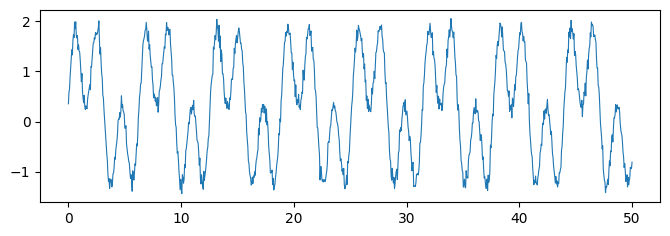

In [7]:
split = int(0.8 * len(X))
Xtr, Xte = X[:split], X[split:]
ytr, yte = y[:split], y[split:]
print('train:', Xtr.shape, 'test:', Xte.shape)

plt.figure(figsize=(8, 2.5));
plt.plot(t, series, lw=0.8)

# LSTM Regression

In [4]:
class LSTMReg(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, (h, c) = self.lstm(x)  # (N, T, H)
        out = out[:, -1, :]       # (N, H) - 마지막 타임스텝의 출력
        out = self.fc(out)     # (N, 1)
        return out
    
model = LSTMReg().to(DEV)
print(model)

LSTMReg(
  (lstm): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


Epoch 0, Loss: 0.6397
Epoch 5, Loss: 0.0194
Epoch 10, Loss: 0.0155
Epoch 15, Loss: 0.0153
Epoch 20, Loss: 0.0151
Epoch 25, Loss: 0.0149


<Axes: title={'center': 'LSTMReg Loss'}, xlabel='epoch', ylabel='loss'>

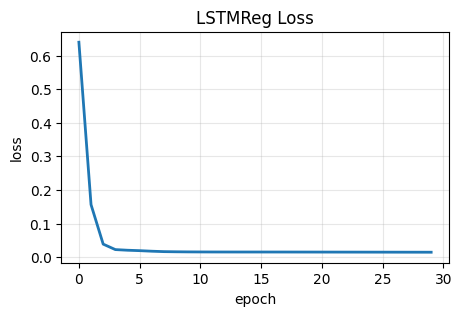

In [8]:
opt = torch.optim.Adam(model.parameters(), lr=5e-3)
loss_fn = nn.MSELoss()

hist = []
for ep in range(30):
    model.train()
    ep_loss = 0

    for i in range(0, len(Xtr), 64):
        xb = Xtr[i:i+64].to(DEV)
        yb = ytr[i:i+64].to(DEV)
        y_pred = model(xb)
        loss = loss_fn(y_pred, yb)
        opt.zero_grad()
        loss.backward()
        opt.step()
        
        ep_loss += loss.item() * xb.size(0)
    hist.append(ep_loss / len(Xtr))
    if ep % 5 == 0:
        print(f'Epoch {ep}, Loss: {hist[-1]:.4f}')
plot_loss(hist, title='LSTMReg Loss')